In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('darkgrid')

os.makedirs('plots', exist_ok=True)
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('../data/dataCleaned.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPrice stats:")
print(df['price'].describe())
df.head()

Shape: (96125, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'mpg', 'engineSize', 'brand']

Price stats:
count    96125.000000
mean     16567.395984
std       9472.798476
min       1000.000000
25%       9998.000000
50%      14200.000000
75%      20490.000000
max      99950.000000
Name: price, dtype: float64


,model,year,price,transmission,mileage,fuelType,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,49.6,1.0,Audi


Category distribution:
  Budget (0): 24,981 cars (26.0%)
  Mid-Range (1): 46,472 cars (48.3%)
  Premium (2): 24,672 cars (25.7%)


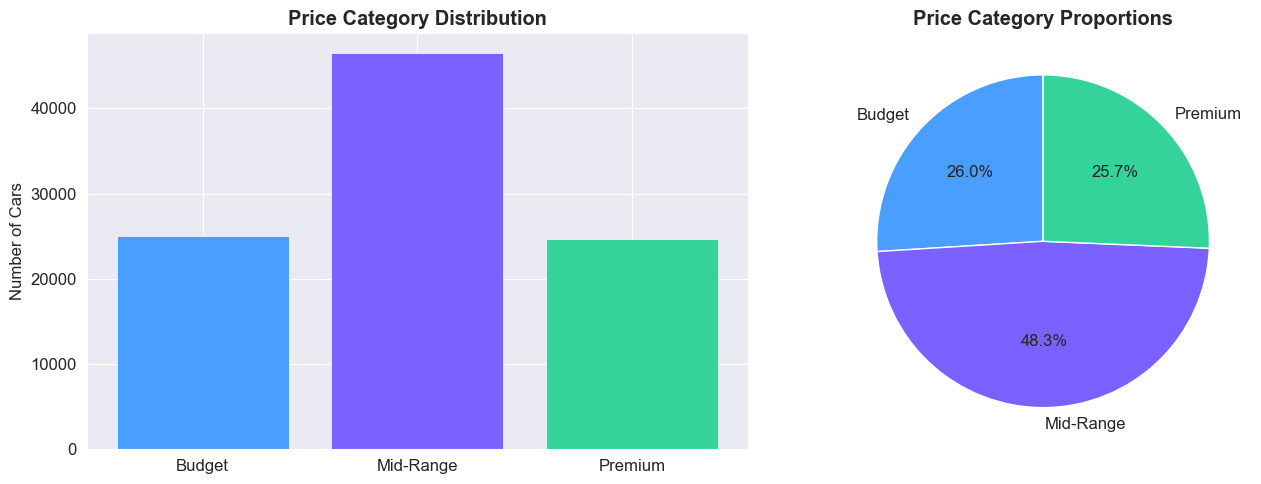

Target variable created!


In [4]:
bins   = [0, 10000, 20000, 100000]
labels = [0, 1, 2]
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels).astype(int)

label_names = {0: 'Budget', 1: 'Mid-Range', 2: 'Premium'}

print("Category distribution:")
counts = df['price_category'].value_counts().sort_index()
for cat, count in counts.items():
    print(f"  {label_names[cat]} ({cat}): {count:,} cars ({count/len(df)*100:.1f}%)")

colors = ['#4a9eff', '#7b61ff', '#34d399']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([label_names[i] for i in sorted(counts.index)],
            [counts[i] for i in sorted(counts.index)],
            color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Price Category Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Cars')

axes[1].pie([counts[i] for i in sorted(counts.index)],
            labels=[label_names[i] for i in sorted(counts.index)],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Price Category Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Target variable created!")

In [20]:
df_ml = df.copy()

# Car age
df_ml['car_age'] = df_ml['year'].max() - df_ml['year'] 
df_ml = df_ml.drop(columns=['year'])

# Log transform mileage
df_ml['mileage'] = np.log1p(df_ml['mileage'])

# One-hot encode
df_ml = pd.get_dummies(df_ml, columns=['brand', 'model', 'fuelType', 'transmission'], drop_first=False)

print("Shape after encoding:", df_ml.shape)

X = df_ml.drop(columns=['price', 'price_category'])
y = df_ml['price_category']

print("Features:", X.shape[1])
print("Target classes:", sorted(y.unique()))

Shape after encoding: (96125, 215)
Features: 213
Target classes: [np.int64(0), np.int64(1), np.int64(2)]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['mileage', 'engineSize', 'mpg', 'car_age']
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"Features:      {X_train.shape[1]}")

Training set:  76,900 rows
Test set:      19,225 rows
Features:      213


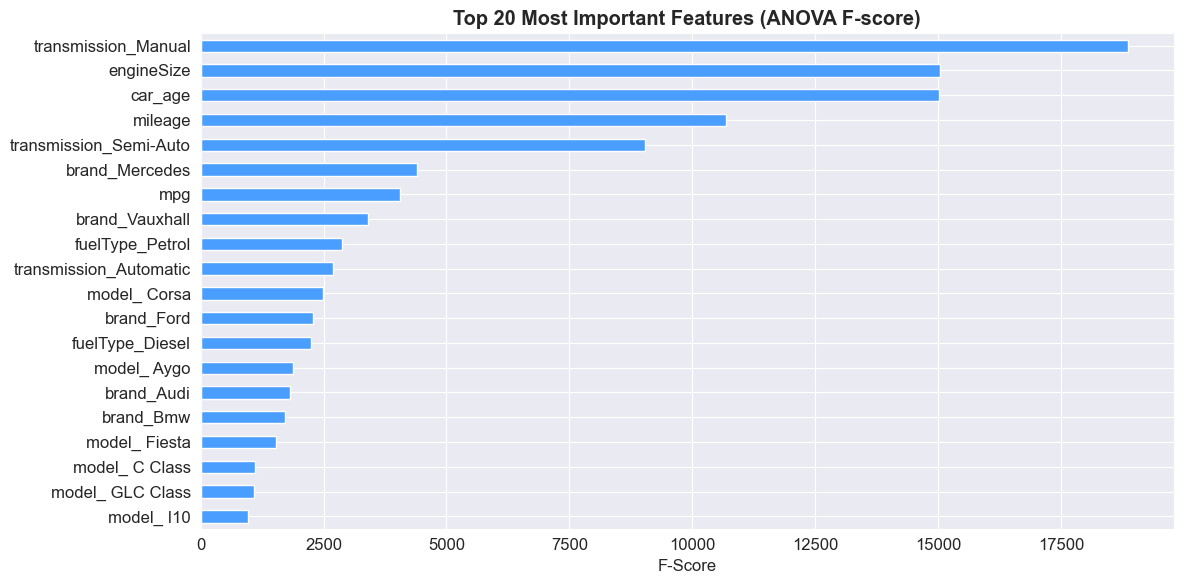

Top 10 features:
  transmission_Manual: 18855.3
  engineSize: 15040.1
  car_age: 15017.1
  mileage: 10687.9
  transmission_Semi-Auto: 9035.0
  brand_Mercedes: 4393.0
  mpg: 4048.5
  brand_Vauxhall: 3395.7
  fuelType_Petrol: 2881.5
  transmission_Automatic: 2699.5

Feature counts: All=213, Top50=50, Top20=20


In [7]:

# Select top 50 features
selector_50 = SelectKBest(f_classif, k=50)
X_train_50 = selector_50.fit_transform(X_train, y_train)
X_test_50  = selector_50.transform(X_test)

# Select top 20 features
selector_20 = SelectKBest(f_classif, k=20)
X_train_20 = selector_20.fit_transform(X_train, y_train)
X_test_20  = selector_20.transform(X_test)

# Show top 20 most important features
feature_scores = pd.Series(selector_50.scores_, index=X_train.columns)
top_features = feature_scores.nlargest(20)

plt.figure(figsize=(12, 6))
top_features.sort_values().plot(kind='barh', color='#4a9eff', edgecolor='white')
plt.title('Top 20 Most Important Features (ANOVA F-score)', fontweight='bold')
plt.xlabel('F-Score')
plt.tight_layout()
plt.savefig('plots/02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
for feat, score in feature_scores.nlargest(10).items():
    print(f"  {feat}: {score:.1f}")

configs = ['All Features', 'Top 50', 'Top 20']
print(f"\nFeature counts: All={X_train.shape[1]}, Top50=50, Top20=20")

In [8]:
# Baseline Logistic Regression
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)
lr_base_pred = lr_base.predict(X_test)

print("Baseline Logistic Regression Results:")
print(f"  Accuracy:  {accuracy_score(y_test, lr_base_pred):.4f}")
print(f"  Precision: {precision_score(y_test, lr_base_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, lr_base_pred, average='weighted'):.4f}")
print(f"  F1:        {f1_score(y_test, lr_base_pred, average='weighted'):.4f}")

Baseline Logistic Regression Results:
  Accuracy:  0.8867
  Precision: 0.8871
  Recall:    0.8867
  F1:        0.8867


In [9]:
param_grid_lr = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'solver':   ['lbfgs', 'saga'],
    'penalty':  ['l2'],
    'max_iter': [1000]
}

print("Running GridSearchCV for Logistic Regression...")
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train, y_train)

print(f"\nBest parameters: {grid_lr.best_params_}")
print(f"Best CV F1 score: {grid_lr.best_score_:.4f}")

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 score: 0.8854


Best Logistic Regression Results:
              precision    recall  f1-score   support

      Budget       0.90      0.86      0.88      4996
   Mid-Range       0.87      0.90      0.88      9295
     Premium       0.90      0.89      0.90      4934

    accuracy                           0.89     19225
   macro avg       0.89      0.88      0.89     19225
weighted avg       0.89      0.89      0.89     19225



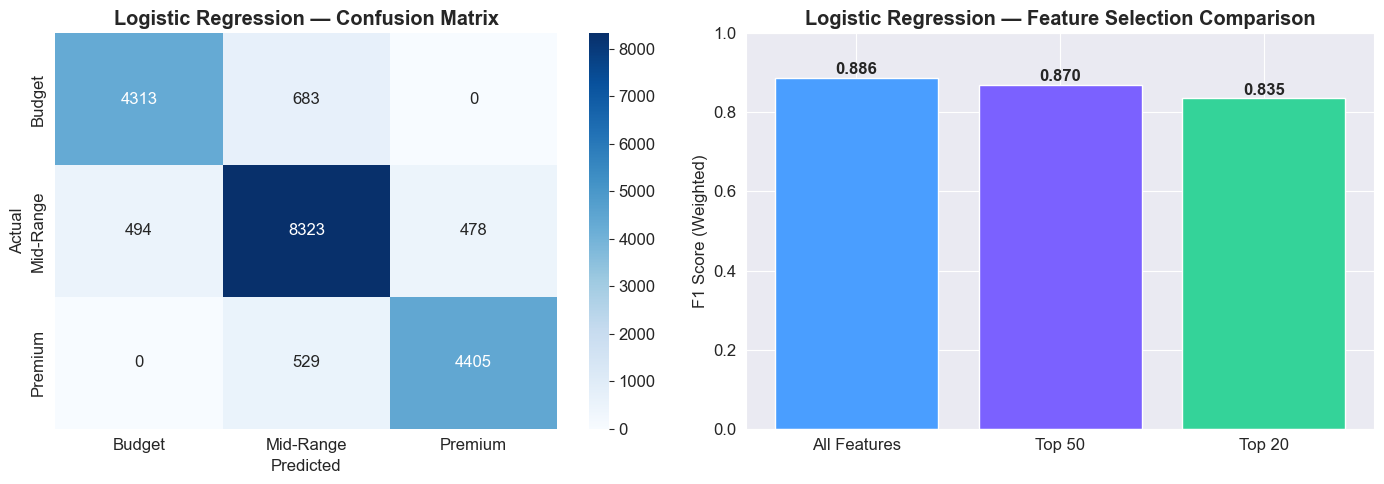

Final — Accuracy: 0.8864 | Precision: 0.8867 | Recall: 0.8864 | F1: 0.8864


In [10]:
lr_best = grid_lr.best_estimator_
lr_pred = lr_best.predict(X_test)

print("Best Logistic Regression Results:")
print(classification_report(y_test, lr_pred, target_names=['Budget', 'Mid-Range', 'Premium']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Budget', 'Mid-Range', 'Premium'],
            yticklabels=['Budget', 'Mid-Range', 'Premium'], ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature selection comparison
lr_scores = []
for Xtr, Xte in [(X_train, X_test), (X_train_50, X_test_50), (X_train_20, X_test_20)]:
    m = LogisticRegression(**{k: v for k, v in grid_lr.best_params_.items()}, random_state=42)
    m.fit(Xtr, y_train)
    lr_scores.append(f1_score(y_test, m.predict(Xte), average='weighted'))

axes[1].bar(configs, lr_scores, color=['#4a9eff', '#7b61ff', '#34d399'], edgecolor='white')
axes[1].set_title('Logistic Regression — Feature Selection Comparison', fontweight='bold')
axes[1].set_ylabel('F1 Score (Weighted)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(lr_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/03_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

lr_accuracy  = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall    = recall_score(y_test, lr_pred, average='weighted')
lr_f1        = f1_score(y_test, lr_pred, average='weighted')
print(f"Final — Accuracy: {lr_accuracy:.4f} | Precision: {lr_precision:.4f} | Recall: {lr_recall:.4f} | F1: {lr_f1:.4f}")

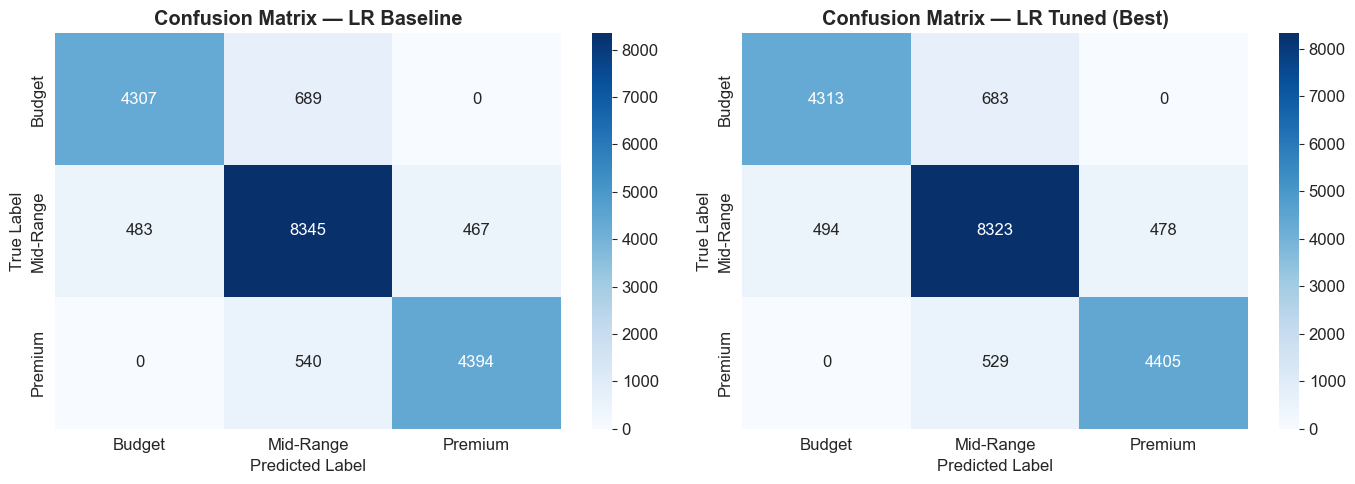

In [11]:
# Confusion Matrix - Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['Budget', 'Mid-Range', 'Premium']

for ax, (preds, title) in zip(axes, [
    (lr_base_pred, 'LR Baseline'),
    (lr_pred, 'LR Tuned (Best)')
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('plots/03_lr_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Baseline KNN
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_50, y_train)   # using Top 50 features (KNN is sensitive to dimensionality)
knn_base_pred = knn_base.predict(X_test_50)

print("=== Baseline KNN (default k=5, Top 50 features) ===")
print(f"Accuracy:  {accuracy_score(y_test, knn_base_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_base_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, knn_base_pred, average='weighted'):.4f}")
print(f"F1:        {f1_score(y_test, knn_base_pred, average='weighted'):.4f}")

=== Baseline KNN (default k=5, Top 50 features) ===
Accuracy:  0.8982
Precision: 0.8983
Recall:    0.8982
F1:        0.8982


In [13]:
# KNN Hyperparameter Tuning
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

print("Running GridSearchCV for KNN (this may take a few minutes)...")
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_knn.fit(X_train_50, y_train)

print(f"\nBest parameters: {grid_knn.best_params_}")
print(f"Best CV F1 score: {grid_knn.best_score_:.4f}")

Running GridSearchCV for KNN (this may take a few minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV F1 score: 0.8983


=== Best KNN (Tuned) ===
Best Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}

Accuracy:  0.9011
Precision: 0.9012
Recall:    0.9011
F1:        0.9011

Classification Report:
              precision    recall  f1-score   support

      Budget       0.91      0.89      0.90      4996
   Mid-Range       0.89      0.91      0.90      9295
     Premium       0.91      0.90      0.91      4934

    accuracy                           0.90     19225
   macro avg       0.90      0.90      0.90     19225
weighted avg       0.90      0.90      0.90     19225



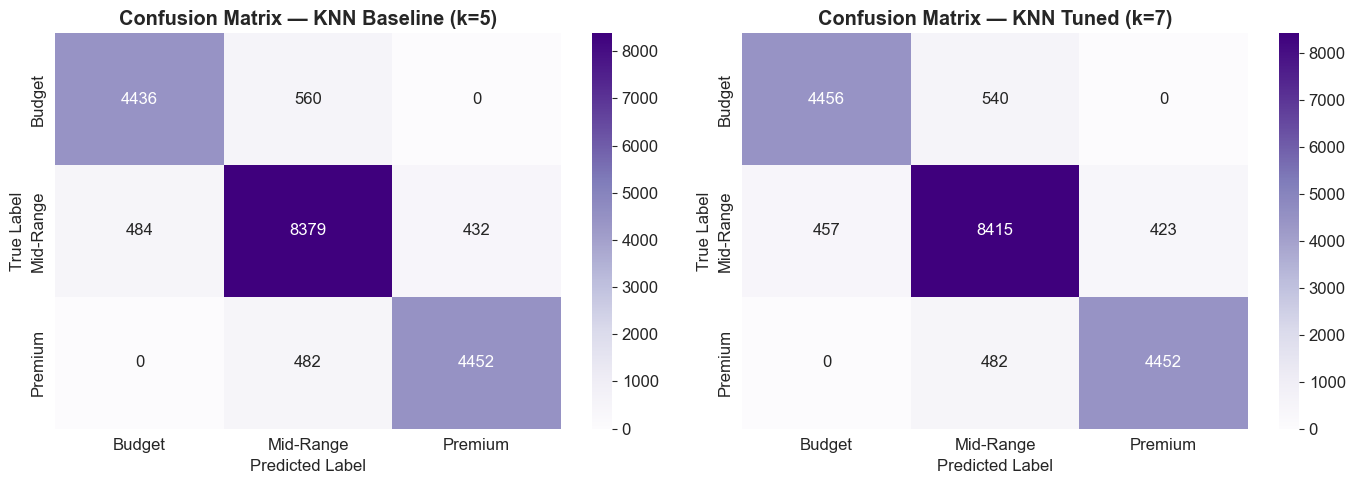

In [14]:
# Best KNN - Evaluation + Confusion Matrix
knn_best = grid_knn.best_estimator_
knn_best_pred = knn_best.predict(X_test_50)

print("=== Best KNN (Tuned) ===")
print(f"Best Params: {grid_knn.best_params_}")
print(f"\nAccuracy:  {accuracy_score(y_test, knn_best_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_best_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, knn_best_pred, average='weighted'):.4f}")
print(f"F1:        {f1_score(y_test, knn_best_pred, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, knn_best_pred, target_names=['Budget', 'Mid-Range', 'Premium']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['Budget', 'Mid-Range', 'Premium']

for ax, (preds, title) in zip(axes, [
    (knn_base_pred, 'KNN Baseline (k=5)'),
    (knn_best_pred, f"KNN Tuned (k={grid_knn.best_params_['n_neighbors']})")
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('plots/04_knn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Final Results Summary Table
results = {
    'Model':     ['LR Baseline', 'LR Tuned', 'KNN Baseline', 'KNN Tuned'],
    'Accuracy':  [
        accuracy_score(y_test, lr_base_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_base_pred),
        accuracy_score(y_test, knn_best_pred),
    ],
    'Precision': [
        precision_score(y_test, lr_base_pred, average='weighted'),
        precision_score(y_test, lr_pred, average='weighted'),
        precision_score(y_test, knn_base_pred, average='weighted'),
        precision_score(y_test, knn_best_pred, average='weighted'),
    ],
    'Recall': [
        recall_score(y_test, lr_base_pred, average='weighted'),
        recall_score(y_test, lr_pred, average='weighted'),
        recall_score(y_test, knn_base_pred, average='weighted'),
        recall_score(y_test, knn_best_pred, average='weighted'),
    ],
    'F1 (weighted)': [
        f1_score(y_test, lr_base_pred, average='weighted'),
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, knn_base_pred, average='weighted'),
        f1_score(y_test, knn_best_pred, average='weighted'),
    ],
    'Best Params': [
        'default',
        str(grid_lr.best_params_),
        'k=5, uniform, euclidean',
        str(grid_knn.best_params_),
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
results_df[['Accuracy','Precision','Recall','F1 (weighted)']] = \
    results_df[['Accuracy','Precision','Recall','F1 (weighted)']].round(4)

print("=== FINAL RESULTS SUMMARY ===")
display(results_df)

results_df.to_csv('plots/classical_models_results.csv')
print("\nResults saved to plots/classical_models_results.csv")

=== FINAL RESULTS SUMMARY ===


,Accuracy,Precision,Recall,F1 (weighted),Best Params
Model,,,,,
LR Baseline,0.8867,0.8871,0.8867,0.8867,default
LR Tuned,0.8864,0.8867,0.8864,0.8864,"{'C': 100, 'max_iter': 1000, 'penalty': 'l2', ..."
KNN Baseline,0.8982,0.8983,0.8982,0.8982,"k=5, uniform, euclidean"
KNN Tuned,0.9011,0.9012,0.9011,0.9011,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei..."



Results saved to plots/classical_models_results.csv


In [ ]:

# CLUSTERING SECTION — KMeans


cluster_cols = ['mileage', 'engineSize', 'mpg', 'car_age']


X_cluster = df_ml[cluster_cols].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

y_true_cluster = df_ml['price_category'].values

print("Clustering data shape:", X_cluster_scaled.shape)
print("Features used:", cluster_cols)

Clustering data shape: (96125, 4)
Features used: ['mileage', 'engineSize', 'mpg', 'car_age']


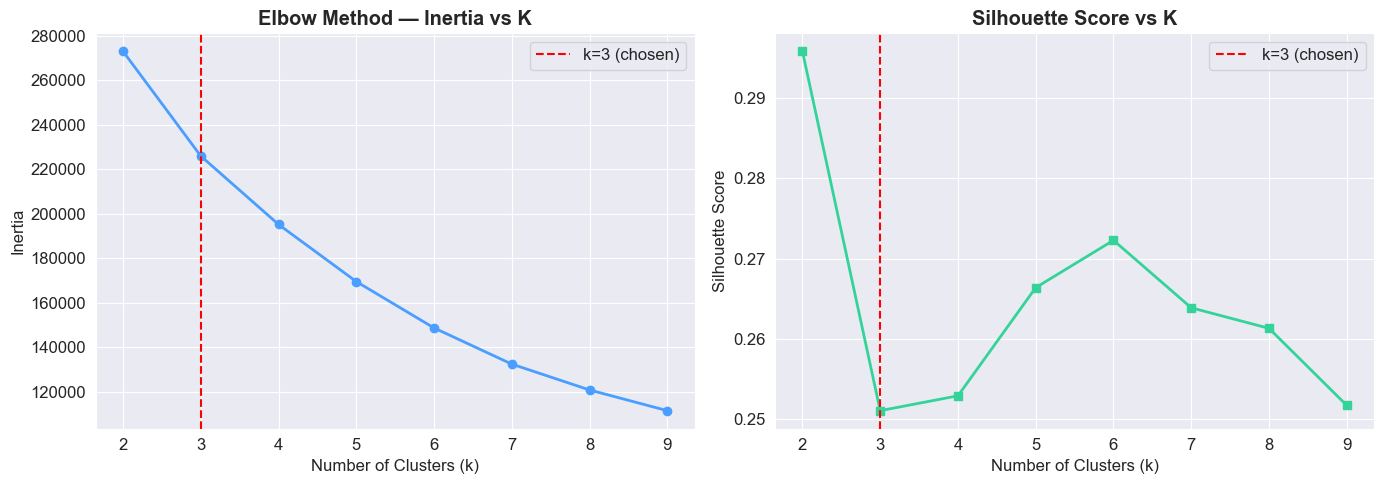

Silhouette scores: {2: 0.2958, 3: 0.2511, 4: 0.2529, 5: 0.2664, 6: 0.2723, 7: 0.2639, 8: 0.2613, 9: 0.2517}


In [ ]:
# Elbow Method 
inertias = []
silhouettes = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'o-', color='#4a9eff', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=3, color='red', linestyle='--', label='k=3 (chosen)')
axes[0].legend()

axes[1].plot(k_range, silhouettes, 's-', color='#34d399', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=3, color='red', linestyle='--', label='k=3 (chosen)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/05_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Silhouette scores: { {k: round(s,4) for k,s in zip(k_range, silhouettes)} }")

In [ ]:
# Experiment with k=2, k=3, k=4 and compare
print("=== Clustering Experiments ===\n")
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled, labels)
    ari = adjusted_rand_score(y_true_cluster, labels)
    print(f"k={k} → Silhouette: {sil:.4f} | ARI vs true labels: {ari:.4f}")

=== Clustering Experiments ===

k=2 → Silhouette: 0.2958 | ARI vs true labels: 0.1540
k=3 → Silhouette: 0.2511 | ARI vs true labels: 0.1319
k=4 → Silhouette: 0.2529 | ARI vs true labels: 0.1254


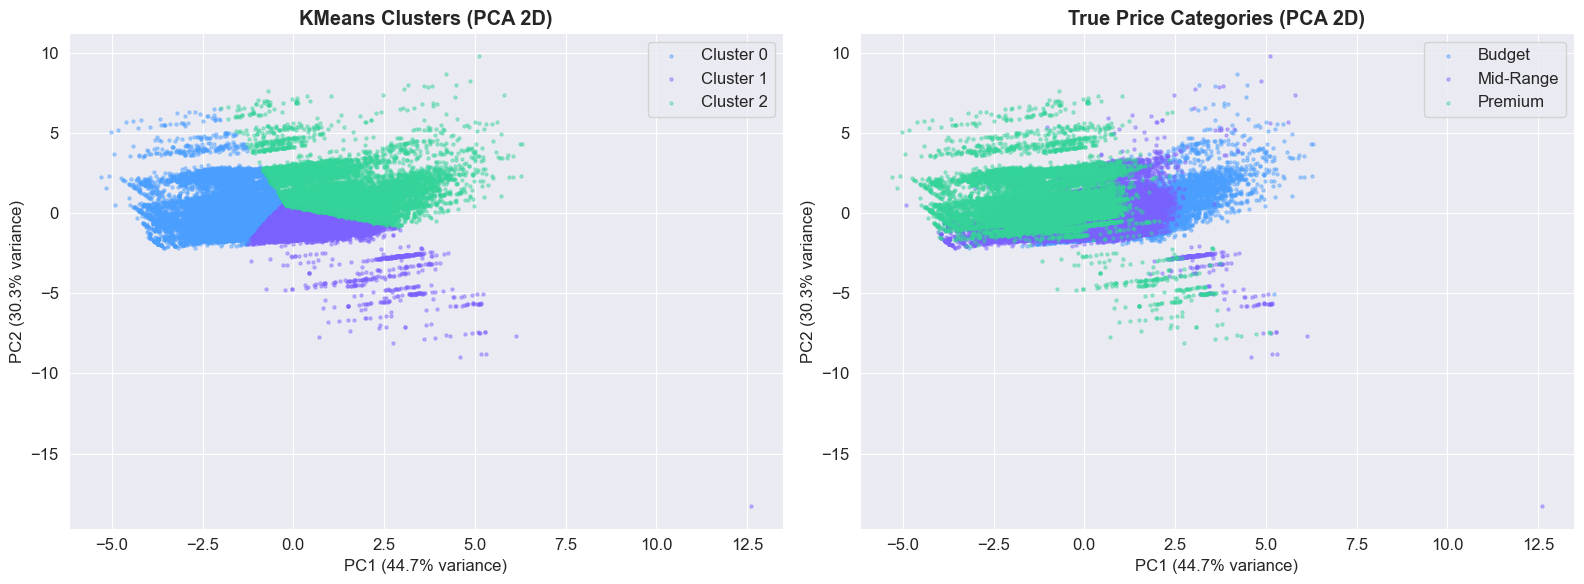

In [ ]:
# Final model: k=3 (matches our 3 price categories)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# PCA to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_cluster = ['#4a9eff', '#7b61ff', '#34d399']
label_names_plot = {0: 'Budget', 1: 'Mid-Range', 2: 'Premium'}

# KMeans clusters
for c in range(3):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_cluster[c], label=f'Cluster {c}',
                    alpha=0.4, s=5)
axes[0].set_title('KMeans Clusters (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# True labels
for c in range(3):
    mask = y_true_cluster == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_cluster[c], label=label_names_plot[c],
                    alpha=0.4, s=5)
axes[1].set_title('True Price Categories (PCA 2D)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/06_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Compare KMeans clusters with true price categories
ari_final = adjusted_rand_score(y_true_cluster, cluster_labels)
sil_final = silhouette_score(X_cluster_scaled, cluster_labels)

print("=== KMeans Final Results (k=3) ===")
print(f"Silhouette Score:        {sil_final:.4f}  (higher = better separated clusters)")
print(f"Adjusted Rand Index:     {ari_final:.4f}  (1.0 = perfect match with true labels)")

# Cross-tabulation: which cluster maps to which price category
import pandas as pd
comparison = pd.crosstab(
    pd.Series(y_true_cluster, name='True Label').map(label_names),
    pd.Series(cluster_labels, name='KMeans Cluster')
)
print("\nCluster vs True Label Cross-tabulation:")
display(comparison)


=== KMeans Final Results (k=3) ===
Silhouette Score:        0.2511  (higher = better separated clusters)
Adjusted Rand Index:     0.1319  (1.0 = perfect match with true labels)

Cluster vs True Label Cross-tabulation:


KMeans Cluster,0,1,2
True Label,,,
Budget,1307,16268,7406
Mid-Range,10338,22461,13673
Premium,17802,2588,4282
